In [ ]:
import os
from pathlib import Path
# Resolve submission_partition_draft root from common launch locations.
def _resolve_partition_root():
    cwd = Path(os.getcwd()).resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "primary_script").exists() and (p / "intermediate").exists():
            return p
        candidate = p / "technical_review" / "submission_partition_draft"
        if (candidate / "primary_script").exists():
            return candidate
    raise RuntimeError("Could not locate submission_partition_draft root")
REPO_ROOT = _resolve_partition_root()


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import scvi
import torch
import warnings
import leidenalg as la
import anndata
from matplotlib import pyplot as plt
from matplotlib.pyplot import rc_context
from scvi.autotune import ModelTuner
from ray import tune
import glob
import re
import csv
import itertools
from scipy.io import mmwrite
import pynndescent
import umap
import random
warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=200)
plt.rcParams['figure.figsize'] = [3,3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
os.chdir(str(REPO_ROOT / 'intermediate'))

In [3]:
adata_myeloid = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid.h5ad'))
adata_platelet = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_platelet.h5ad'))

In [4]:
adata_myeloid.obs['merged_type'].value_counts()

merged_type
CD14 Mono     43976
CD16 Mono     10595
M-platelet     3565
cDC2           3102
pDC            1146
cDC1            184
Name: count, dtype: int64

In [5]:
unique_pid = adata_myeloid.obs['study_id'].values.unique(); unique_pid

['Sadie-011', 'Sadie-016', 'Sadie-018', 'Sadie-038', 'Sadie-036', 'Sadie-023', 'Sadie-029', 'Sadie-026']
Categories (8, object): ['Sadie-011', 'Sadie-016', 'Sadie-018', 'Sadie-023', 'Sadie-026', 'Sadie-029', 'Sadie-036', 'Sadie-038']

In [6]:
def generate_oligo_tag(length=16):
    return ''.join(random.choices('CGAT', k=length))

def generate_unique_oligo_tags(num_tags, length=16):
    unique_tags = set()
    while len(unique_tags) < num_tags:
        new_tag = generate_oligo_tag(length) + '-dbl'
        unique_tags.add(new_tag)
    return list(unique_tags)

In [ ]:
adata_cmo = adata_myeloid[adata_myeloid.obs['merged_type']=='CD14 Mono']
adata_plt = adata_platelet[adata_platelet.obs['merged_type']=='Platelet'] # doesn't actually drop any cells, but just to be safe

In [8]:
common_genes = np.intersect1d(adata_cmo.var_names, adata_plt.var_names)

adata_cmo = adata_cmo[:, common_genes]
adata_plt = adata_plt[:, common_genes]

In [9]:
np.all(adata_cmo.layers['counts'].data == adata_cmo.layers['counts'].data.astype(np.int32))

True

In [10]:
np.all(adata_plt.layers['counts'].data == adata_plt.layers['counts'].data.astype(np.int32))

True

In [11]:
np.mean(adata_cmo.var_names==adata_plt.var_names)

1.0

In [12]:
adata_cmo_sd1 = adata_cmo[adata_cmo.obs['study_day']=='SD1']
adata_cmo_sd2 = adata_cmo[adata_cmo.obs['study_day']=='SD2']
adata_cmo_sd3 = adata_cmo[adata_cmo.obs['study_day']=='SD3']
adata_plt_sd1 = adata_plt[adata_plt.obs['study_day']=='SD1']
adata_plt_sd2 = adata_plt[adata_plt.obs['study_day']=='SD2']
adata_plt_sd3 = adata_plt[adata_plt.obs['study_day']=='SD3']

In [13]:
doublet_list = []
np.random.seed(123)
for i in range(len(unique_pid)):
    tmp_id = unique_pid[i]
    print('formulating anndata object with simulated cMo + Platelet doublets for pid: [' + tmp_id + '] ', str(i+1), ' of ',len(unique_pid), ' pid ...')

    sd1_cmo = adata_cmo_sd1[adata_cmo_sd1.obs['study_id']==tmp_id]
    sd2_cmo = adata_cmo_sd2[adata_cmo_sd2.obs['study_id']==tmp_id]
    sd3_cmo = adata_cmo_sd3[adata_cmo_sd3.obs['study_id']==tmp_id]
    sd1_plt = adata_plt_sd1[adata_plt_sd1.obs['study_id']==tmp_id]
    sd2_plt = adata_plt_sd2[adata_plt_sd2.obs['study_id']==tmp_id]
    sd3_plt = adata_plt_sd3[adata_plt_sd3.obs['study_id']==tmp_id]
    # sd1
    min_sd1 = np.min([sd1_cmo.shape[0],sd1_plt.shape[0]])
    sd1_cmo = sd1_cmo[np.random.choice(sd1_cmo.n_obs, size=min_sd1, replace=False)]
    sd1_plt = sd1_plt[np.random.choice(sd1_plt.n_obs, size=min_sd1, replace=False)]
    #sd1_sim_ct = sd1_cmo.X + sd1_plt.X
    sd1_sim_ct = sd1_cmo.layers['counts'] + sd1_plt.layers['counts']
    assert sd1_cmo.n_obs == sd1_plt.n_obs, "The number of cells in both [SD1] AnnData objects must be the same."
    assert all(sd1_cmo.var_names == sd1_plt.var_names), "The feature names (var_names) in both [SD1] AnnData objects must be the same."
    sd1_adata_sim = anndata.AnnData(sd1_sim_ct, var=sd1_cmo.var)
    sd1_adata_sim.obs['lane'] = [x if x==y else x+'_'+y for x,y in zip(sd1_cmo.obs['lane'],sd1_plt.obs['lane'])]
    sd1_adata_sim.obs['study_day'] = 'SD1'
    # sd2
    min_sd2 = np.min([sd2_cmo.shape[0],sd2_plt.shape[0]])
    sd2_cmo = sd2_cmo[np.random.choice(sd2_cmo.n_obs, size=min_sd2, replace=False)]
    sd2_plt = sd2_plt[np.random.choice(sd2_plt.n_obs, size=min_sd2, replace=False)]
    #sd2_sim_ct = sd2_cmo.X + sd2_plt.X
    sd2_sim_ct = sd2_cmo.layers['counts'] + sd2_plt.layers['counts']
    assert sd2_cmo.n_obs == sd2_plt.n_obs, "The number of cells in both [SD2] AnnData objects must be the same."
    assert all(sd2_cmo.var_names == sd2_plt.var_names), "The feature names (var_names) in both [SD2] AnnData objects must be the same."
    sd2_adata_sim = anndata.AnnData(sd2_sim_ct, var=sd2_cmo.var)
    sd2_adata_sim.obs['lane'] = [x if x==y else x+'_'+y for x,y in zip(sd2_cmo.obs['lane'],sd2_plt.obs['lane'],)]
    sd2_adata_sim.obs['study_day'] = 'SD2'
    # sd3
    min_sd3 = np.min([sd3_cmo.shape[0],sd3_plt.shape[0]])
    sd3_cmo = sd3_cmo[np.random.choice(sd3_cmo.n_obs, size=min_sd3, replace=False)]
    sd3_plt = sd3_plt[np.random.choice(sd3_plt.n_obs, size=min_sd3, replace=False)]
    #sd3_sim_ct = sd3_cmo.X + sd3_plt.X
    sd3_sim_ct = sd3_cmo.layers['counts'] + sd3_plt.layers['counts']
    assert sd3_cmo.n_obs == sd3_plt.n_obs, "The number of cells in both [SD3] AnnData objects must be the same."
    assert all(sd3_cmo.var_names == sd3_plt.var_names), "The feature names (var_names) in both [SD3] AnnData objects must be the same."
    sd3_adata_sim = anndata.AnnData(sd3_sim_ct, var=sd3_cmo.var)
    sd3_adata_sim.obs['lane'] = [x if x==y else x+'_'+y for x,y in zip(sd3_cmo.obs['lane'],sd3_plt.obs['lane'],)]
    sd3_adata_sim.obs['study_day'] = 'SD3'

    doublet_adata = anndata.concat([sd1_adata_sim, sd2_adata_sim, sd3_adata_sim])
    num_tags = doublet_adata.n_obs
    unique_oligo_tags = generate_unique_oligo_tags(num_tags)
    oligo_tags = [generate_oligo_tag() + '-dbl' for _ in range(doublet_adata.n_obs)]
    doublet_adata.obs_names = oligo_tags
    doublet_adata.obs['study_id'] = tmp_id
    doublet_adata.obs['map_sd'] = [x.replace('-','').upper()+'_'+y.replace('MM-','') for x,y in zip(doublet_adata.obs['study_id'],doublet_adata.obs['lane'])]
    doublet_adata.obs['souporcell_status'] = 'sim_doublet'
    doublet_adata.obs['souporcell_assignment'] = tmp_id
    doublet_adata.obs['barcode_2'] = doublet_adata.obs_names
    doublet_adata.obs['solo_prediction'] = 'cMo_Platelet_doublet'
    doublet_adata.var['MT'] = doublet_adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(doublet_adata, inplace=True, qc_vars = ['MT'])
    doublet_list.append(doublet_adata)
concatenated_doublets = anndata.concat(doublet_list)

formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-011]  1  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-016]  2  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-018]  3  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-038]  4  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-036]  5  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-023]  6  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-029]  7  of  8  pid ...
formulating anndata object with simulated cMo + Platelet doublets for pid: [Sadie-026]  8  of  8  pid ...


In [14]:
adata_myeloid.X = adata_myeloid.layers['counts']
np.all(adata_myeloid.X.data == adata_myeloid.X.data.astype(np.int32))

True

In [15]:
np.all(concatenated_doublets.X.data == concatenated_doublets.X.data.astype(np.int32))

True

In [16]:
adata_plt.X = adata_plt.layers['counts']
np.all(adata_plt.X.data == adata_plt.X.data.astype(np.int32))

True

In [17]:
sim_adata_concat = anndata.concat([adata_myeloid, adata_plt, concatenated_doublets])

In [18]:
np.all(sim_adata_concat.X.data == sim_adata_concat.X.data.astype(np.int32))

True

In [19]:
adata_plt.obs['barcode_2'] = [x+'-plt' for x in adata_plt.obs['barcode_2']]

In [20]:
sim_adata_concat.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_simulation_dataset.h5ad'))

In [22]:
adata = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_simulation_dataset.h5ad'))
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_genes(adata, min_cells = 10)
adata.var['MT'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['MT'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs['pct_counts_MT'] <= 10]
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=2500, subset = False, layer = 'counts', 
                            flavor = "seurat_v3", batch_key="lane")
adata_var = adata.var
csv_data = pd.read_csv(str(REPO_ROOT / 'primary_dependents' / 'EXCLUDE_XY_TCR_IG.csv'), header = None)

positions = np.where(adata.var_names.isin(csv_data[0]))[0]
adata.var.iloc[positions, adata.var.columns.get_loc('highly_variable')] = False
adata.var['highly_variable'].value_counts()

highly_variable
False    18268
True      2317
Name: count, dtype: int64

In [ ]:
model_cls = scvi.model.SCVI
model_cls.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                        categorical_covariate_keys=['study_id'], 
                        continuous_covariate_keys=['pct_counts_MT', 'total_counts'])
tuner = ModelTuner(model_cls)
search_space = {
    "n_hidden": tune.choice([92, 128, 192, 256]),
    "n_latent": tune.choice([10, 20, 30, 40, 50, 60]),
    "n_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "gene_likelihood": tune.choice(["nb", "zinb"])}
results = tuner.fit(adata, metric="validation_loss",
                    resources = {'gpu': 1}, 
                    search_space = search_space,
                    num_samples = 100,
                    max_epochs = 20)

In [24]:
best_vl = 10000
best_i = 0
for i in range(len(results.results)):
    if 'validation_loss' in results.results[i].metrics.keys():
        vl = results.results[i].metrics['validation_loss']
        if vl < best_vl:
            best_vl = vl
            best_i = i
    else:
        continue
tuner_res = str(results.results[best_i])
tuner_res

"Result(\n  metrics={'validation_loss': 4242.974609375},\n  path='/media/MPEdge16/MM137/sc/py/scvi_log/autotune/2024-11-11_21-57-17_scvi/_trainable_b06904b2_68_gene_likelihood=zinb,lr=0.0069,n_hidden=128,n_latent=60,n_layers=2_2024-11-11_22-46-14',\n  filesystem='local',\n  checkpoint=None\n)"

In [25]:
match_gene_likelihood_1 = re.compile(r'gene_likelihood=(nb|zinb)')
gl_1 = match_gene_likelihood_1.search(tuner_res).group()
match_gene_likelihood_2 = re.compile(r'(nb|zinb)')
gene_likelihood_param = match_gene_likelihood_2.search(gl_1).group()

In [26]:
nlayer_1 = re.compile(r'n_layers=[0-9]+')
nl_1 = nlayer_1.search(tuner_res).group()
nlayer_2 = re.compile(r'[0-9]+')
n_layers_param = int(nlayer_2.search(nl_1).group())

In [27]:
nlatent_1 = re.compile(r'n_latent=[0-9]+')
nlat_1 = nlatent_1.search(tuner_res).group()
nlatent_2 = re.compile(r'[0-9]+')
n_latent_param = int(nlatent_2.search(nlat_1).group())

In [28]:
nhidden_1 = re.compile(r'n_hidden=[0-9]+')
nh_1 = nhidden_1.search(tuner_res).group()
nhidden_2 = re.compile(r'[0-9]+')
n_hidden_param = int(nhidden_2.search(nh_1).group())

In [29]:
learn_1 = re.compile(r'lr=[0-9\\.]+')
lr_1 = learn_1.search(tuner_res).group()
learn_2 = re.compile(r'[0-9\\.]+')
lr_param = float(learn_2.search(lr_1).group())

In [30]:
{'n_hidden': n_hidden_param, 
'n_latent': n_latent_param, 
'n_layers': n_layers_param, 
'gene_likelihood': gene_likelihood_param, 
'lr': lr_param}

{'n_hidden': 128,
 'n_latent': 60,
 'n_layers': 2,
 'gene_likelihood': 'zinb',
 'lr': 0.0069}

In [31]:
scvi.model.SCVI.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                              categorical_covariate_keys=['study_id'], 
                              continuous_covariate_keys=['pct_counts_MT', 'total_counts'])
model = scvi.model.SCVI(adata, n_hidden = n_hidden_param, n_latent = n_latent_param, n_layers = n_layers_param, gene_likelihood = gene_likelihood_param)
kwargs = {'lr': lr_param}
model.train(max_epochs = 200, early_stopping = True, plan_kwargs = kwargs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX 4000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 200/200: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 200/200 [29:39<00:00,  9.44s/it, v_num=1, train_loss_step=4.21e+3, train_loss_epoch=4.25e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 200/200 [29:39<00:00,  8.90s/it, v_num=1, train_loss_step=4.21e+3, train_loss_epoch=4.25e+3]


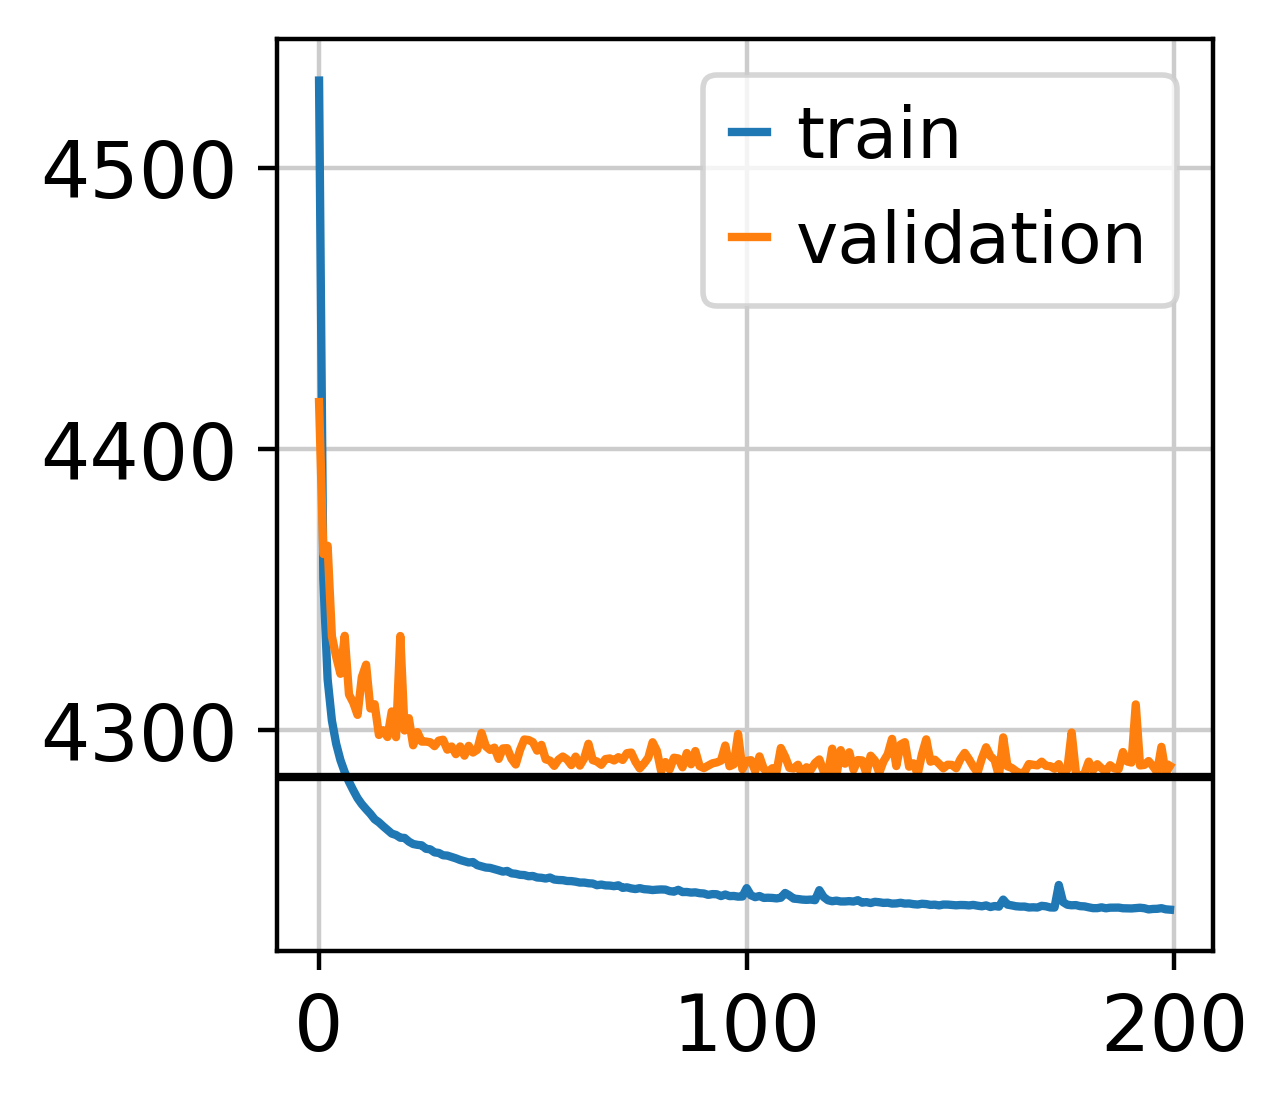

In [32]:
y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()
plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')

plt.axhline(y, c = 'k')

plt.legend()
plt.show()

In [ ]:
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'temp_pbmc_myeloid_platelet_sim.h5ad'))
adata = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'temp_pbmc_myeloid_platelet_sim.h5ad'))
#model.save('pbmc/pbmc_myeloid_platelet_scvi_integration_model_sim')
model = scvi.model.SCVI.load(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid_platelet_scvi_integration_model_sim/'), adata)

INFO     File /media/MPEdge16/MM137/sc/py/py_out/pbmc/pbmc_myeloid_platelet_scvi_integration_model_sim/model.pt    
         already downloaded                                                                                        


In [4]:
adata.obsm['X_scVI'] = model.get_latent_representation()
scvi_norm_count = model.get_normalized_expression(library_size = 1e4)
adata.layers['scvi_normalized'] = scvi_norm_count

In [5]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 123)

In [7]:
sc.tl.umap(adata)

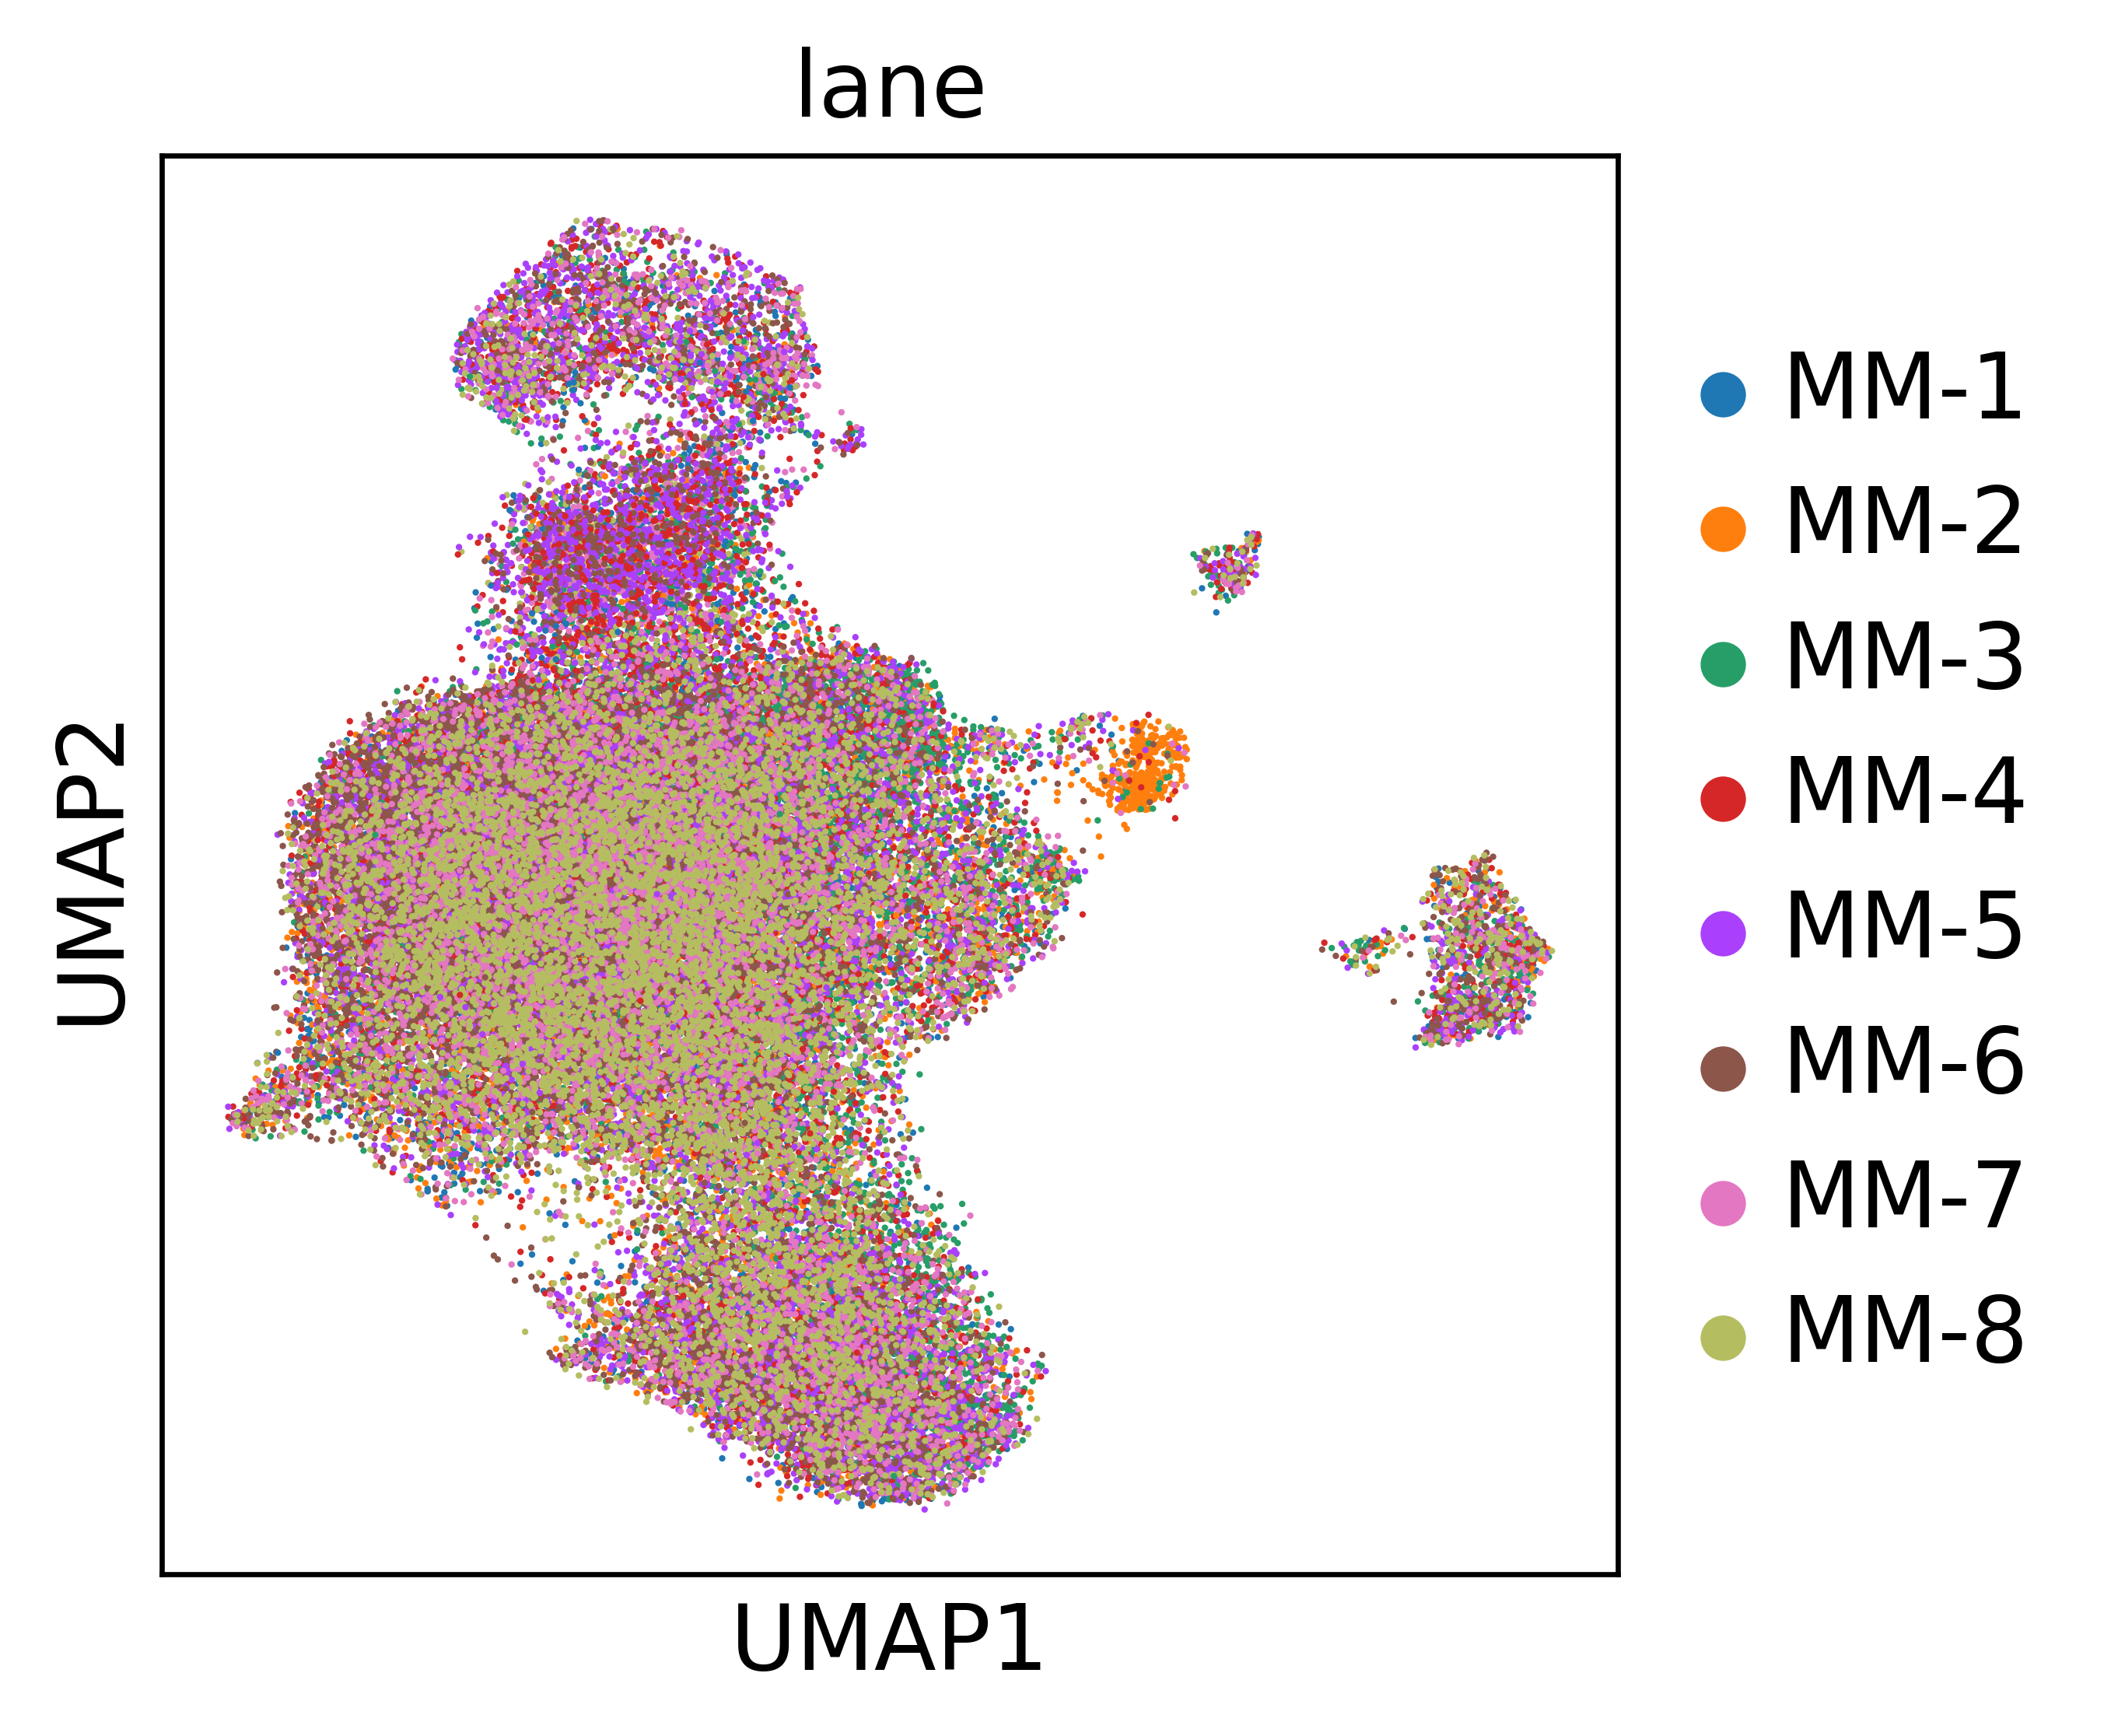

In [8]:
sc.set_figure_params(dpi=300)
sc.pl.umap(adata, color = 'lane', size = 4, legend_fontsize = 'medium')

In [ ]:
sc.pl.umap(adata, color = 'study_id', size = 4, legend_fontsize = 'medium')

In [ ]:
sc.pl.umap(adata, color = 'study_day', size = 4, legend_fontsize = 'medium')

In [ ]:
sc.set_figure_params(dpi=200)
sc.pl.umap(adata, color = ['CD14','FCGR3A','LYZ','PLD4','ITM2C','S100A9','NEAT1','LILRA4','CLEC9A','HLA-DQA1','FCER1A','IRF4'], size = 4, frameon = False, layer = 'scvi_normalized')

In [16]:
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_myeloid_platelet_int_sim.h5ad'))

In [11]:
np.savetxt(fname = str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/pbmc_mpa_sim_umap_coordinates.csv'), 
           X = adata.obsm['X_umap'], delimiter = ',')

In [ ]:
rna_counts = adata.layers['counts'] # whole integer counts, no normalization
adata_obs = adata.obs
adata_var = adata.var
mmwrite(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_counts_mpa_sim.mtx'), rna_counts)
adata_obs.to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_obs_mpa_sim.csv'))
adata_var.to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_var_mpa_sim.csv'))